# Literature Review Plan — MTD under APT & IDS

**Project:** 24-point Research Project (5,000–6,000 words incl. references, 10–20 refs, IEEE style)  
**RQ1:** How does MTD behave under APT attack profiles?  
**RQ2:** (Building on RQ1) How does MTD behave under IDS integration?  

---

## Concept Graph

```mermaid
flowchart TD
    classDef section fill:#2d5986,stroke:#1a3a5c,color:#fff,font-weight:bold
    classDef subsection fill:#4a90c4,stroke:#2d5986,color:#fff
    classDef gap fill:#c0392b,stroke:#922b21,color:#fff,font-weight:bold
    classDef approach fill:#27ae60,stroke:#1e8449,color:#fff,font-weight:bold
    classDef rq fill:#8e44ad,stroke:#6c3483,color:#fff,font-weight:bold

    S1["§1 Moving Target Defense"]:::section
    S1a["1.1 MTD Concept & Taxonomy\n(shuffle, diversity, redundancy)"]:::subsection
    S1b["1.2 Foundational MTD Research\n(single attacker + single network\n→ optimised defence)"]:::subsection
    S1c["1.3 MTD Orchestration\n(simultaneous, alternative,\nrandom — SDR strategies)"]:::subsection

    S2["§2 Threat Landscape &\nAttack Modelling"]:::section
    S2a["2.1 MITRE ATT&CK Framework\n(tactics, techniques, procedures)"]:::subsection
    S2b["2.2 Pyramid of Pain\n(indicators → tools → TTPs)"]:::subsection
    S2c["2.3 Advanced Persistent Threats\n(APT definition & characteristics)"]:::subsection
    S2d["2.4 Attack Profiling Approaches\n(behavioural, capability-based,\ncampaign-driven)"]:::subsection

    S3["§3 Attack Modelling in\nMTD Simulation"]:::section
    S3a["3.1 Current Attacker Models\nin MTD Literature\n(simple, uniform, single-phase)"]:::subsection
    S3b["3.2 Pyramid of Pain in MTD\n(hash/IP-level defence ≠\nTTP-level threat modelling)"]:::subsection
    G1["GAP: TTP-driven APT profiling\nabsent from MTD evaluation"]:::gap

    S4["§4 Intrusion Detection &\nMTD Integration"]:::section
    S4a["4.1 IDS Fundamentals\n(signature, anomaly, hybrid)"]:::subsection
    S4b["4.2 MTD + IDS Integration\n(emerging frontier)"]:::subsection
    G2["GAP: Adaptive MTD selection\nunder IDS not evaluated\nagainst realistic threat profiles"]:::gap

    S5["§5 Research Gap & Approach"]:::approach
    RQ1["RQ1: How does MTD behave\nunder APT attack profiles?"]:::rq
    RQ2["RQ2: How does MTD behave\nunder IDS integration?"]:::rq

    S1 --> S1a --> S1b --> S1c
    S1c --> S2

    S2 --> S2a --> S2b --> S2c --> S2d
    S2d --> S3

    S3 --> S3a --> S3b --> G1
    G1 --> S4

    S4 --> S4a --> S4b --> G2
    G2 --> S5

    S5 --> RQ1
    RQ1 --> RQ2
```

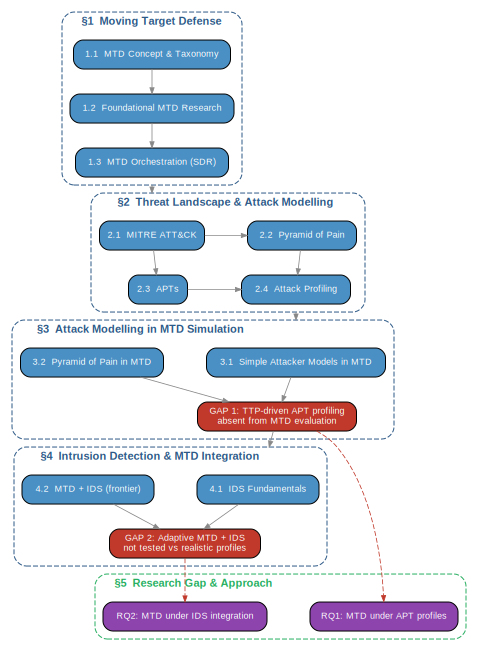

In [5]:
import graphviz

g = graphviz.Digraph(
    "lit_review",
    format="png",
    graph_attr={
        "rankdir": "TB", "splines": "true", "nodesep": "0.6", "ranksep": "0.35",
        "bgcolor": "white", "compound": "true", "newrank": "true",
    },
    node_attr={
        "shape": "box", "style": "filled,rounded", "fontname": "Helvetica",
        "fontsize": "9", "margin": "0.12,0.06", "height": "0.4",
    },
    edge_attr={"color": "#888888", "arrowsize": "0.6", "penwidth": "0.8"},
)

# Colour palette
SEC = "#2d5986"; SUB = "#4a90c4"; GAP = "#c0392b"; APP = "#27ae60"; RQ = "#8e44ad"

# ── §1 Moving Target Defense ─────────────────────────────────────────────
with g.subgraph(name="cluster_s1") as c:
    c.attr(label="§1  Moving Target Defense", labeljust="l", style="rounded,dashed",
           color="#2d5986", fontcolor="#2d5986", fontname="Helvetica-Bold", fontsize="11")
    c.node("S1a", "1.1  MTD Concept & Taxonomy", fillcolor=SUB, fontcolor="white")
    c.node("S1b", "1.2  Foundational MTD Research", fillcolor=SUB, fontcolor="white")
    c.node("S1c", "1.3  MTD Orchestration (SDR)", fillcolor=SUB, fontcolor="white")
    c.edge("S1a", "S1b")
    c.edge("S1b", "S1c")

# ── §2 Threat Landscape & Attack Modelling ────────────────────────────────
with g.subgraph(name="cluster_s2") as c:
    c.attr(label="§2  Threat Landscape & Attack Modelling", labeljust="l", style="rounded,dashed",
           color="#2d5986", fontcolor="#2d5986", fontname="Helvetica-Bold", fontsize="11")
    c.node("S2a", "2.1  MITRE ATT&CK", fillcolor=SUB, fontcolor="white")
    c.node("S2b", "2.2  Pyramid of Pain", fillcolor=SUB, fontcolor="white")
    c.node("S2c", "2.3  APTs", fillcolor=SUB, fontcolor="white")
    c.node("S2d", "2.4  Attack Profiling", fillcolor=SUB, fontcolor="white")
    # lay out 2x2 grid
    with c.subgraph() as r:
        r.attr(rank="same")
        r.node("S2a"); r.node("S2b")
    with c.subgraph() as r:
        r.attr(rank="same")
        r.node("S2c"); r.node("S2d")
    c.edge("S2a", "S2c")
    c.edge("S2b", "S2d")
    c.edge("S2a", "S2b")
    c.edge("S2c", "S2d")

# ── §3 Attack Modelling in MTD Simulation ─────────────────────────────────
with g.subgraph(name="cluster_s3") as c:
    c.attr(label="§3  Attack Modelling in MTD Simulation", labeljust="l", style="rounded,dashed",
           color="#2d5986", fontcolor="#2d5986", fontname="Helvetica-Bold", fontsize="11")
    c.node("S3a", "3.1  Simple Attacker Models in MTD", fillcolor=SUB, fontcolor="white")
    c.node("S3b", "3.2  Pyramid of Pain in MTD", fillcolor=SUB, fontcolor="white")
    c.node("G1",  "GAP 1: TTP-driven APT profiling\nabsent from MTD evaluation", fillcolor=GAP, fontcolor="white", fontsize="9")
    with c.subgraph() as r:
        r.attr(rank="same")
        r.node("S3a"); r.node("S3b")
    c.edge("S3a", "G1")
    c.edge("S3b", "G1")

# ── §4 Intrusion Detection & MTD Integration ─────────────────────────────
with g.subgraph(name="cluster_s4") as c:
    c.attr(label="§4  Intrusion Detection & MTD Integration", labeljust="l", style="rounded,dashed",
           color="#2d5986", fontcolor="#2d5986", fontname="Helvetica-Bold", fontsize="11")
    c.node("S4a", "4.1  IDS Fundamentals", fillcolor=SUB, fontcolor="white")
    c.node("S4b", "4.2  MTD + IDS (frontier)", fillcolor=SUB, fontcolor="white")
    c.node("G2",  "GAP 2: Adaptive MTD + IDS\nnot tested vs realistic profiles", fillcolor=GAP, fontcolor="white", fontsize="9")
    with c.subgraph() as r:
        r.attr(rank="same")
        r.node("S4a"); r.node("S4b")
    c.edge("S4a", "G2")
    c.edge("S4b", "G2")

# ── §5 Research Gap & Approach ────────────────────────────────────────────
with g.subgraph(name="cluster_s5") as c:
    c.attr(label="§5  Research Gap & Approach", labeljust="l", style="rounded,dashed",
           color="#27ae60", fontcolor="#27ae60", fontname="Helvetica-Bold", fontsize="11")
    c.node("RQ1", "RQ1: MTD under APT profiles", fillcolor=RQ, fontcolor="white")
    c.node("RQ2", "RQ2: MTD under IDS integration", fillcolor=RQ, fontcolor="white")
    with c.subgraph() as r:
        r.attr(rank="same")
        r.node("RQ1"); r.node("RQ2")

# ── Cross-section edges ──────────────────────────────────────────────────
g.edge("S1c", "S2a", lhead="cluster_s2", ltail="cluster_s1")
g.edge("S2d", "S3a", lhead="cluster_s3", ltail="cluster_s2")
g.edge("G1",  "S4a", lhead="cluster_s4")
g.edge("G1",  "RQ1", style="dashed", color="#c0392b")
g.edge("G2",  "RQ2", style="dashed", color="#c0392b")

g

---

## §1 Moving Target Defense (~1,000–1,200 words)

**Narrative arc:** Broad introduction to MTD → taxonomy of techniques → foundational evaluation paradigm (1 attacker, 1 network, optimise defence) → orchestration strategies that go beyond single-technique deployment.

### 1.1 MTD Concept & Taxonomy

**Goal:** Define MTD and situate it within the proactive defence landscape.  

**Key points to cover:**
- MTD as a paradigm shift from static to dynamic defence surfaces
- Three-category taxonomy: shuffle, diversity, redundancy
- Defence layers: network (IP, topology), application (OS, services, ports), reserve (users)

**References to find:**
- [ ] Seminal MTD definition paper
- [ ] MTD taxonomy/survey paper

**Notes:**


### 1.2 Foundational MTD Research

**Goal:** Characterise the dominant evaluation paradigm — single attacker vs. single network, optimise one defence technique.

**Key points to cover:**
- Typical evaluation setup: one attacker model, one network topology, measure MTTC / compromise ratio
- Game-theoretic and Markov-based analysis approaches
- Limitation: isolated technique evaluation doesn't reflect real deployment

**References to find:**
- [ ] Representative foundational MTD evaluation paper(s)
- [ ] Game-theoretic MTD paper

**Notes:**


### 1.3 MTD Orchestration

**Goal:** Introduce the concept of deploying *multiple* MTD techniques via orchestration strategies (SDR).

**Key points to cover:**
- Simultaneous, alternative (round-robin), random deployment schemes
- Resource contention across defence layers (network, application, reserve)
- Why orchestration matters: individual techniques have complementary coverage
- Transition to: if we orchestrate multiple MTDs, what do we defend *against*?

**References to find:**
- [ ] SDR / MTD orchestration paper

**Notes:**


---

## §2 Threat Landscape & Attack Modelling (~1,000–1,200 words)

**Narrative arc:** Introduce the frameworks and concepts that structure how we understand threats — MITRE ATT&CK as the knowledge base, Pyramid of Pain as the conceptual hierarchy, APTs as the threat class, and attack profiling as the bridge to simulation.

### 2.1 MITRE ATT&CK Framework

**Goal:** Present MITRE ATT&CK as the de facto adversary behaviour knowledge base.

**Key points to cover:**
- Structure: tactics (14 phases), techniques (~600), sub-techniques, procedures
- Data assets: campaigns (C0001–C0059), groups, software, STIX format
- Use in industry and academia for threat intelligence

**References to find:**
- [ ] MITRE ATT&CK primary reference

**Notes:**


### 2.2 Pyramid of Pain

**Goal:** Frame the hierarchy of adversary indicators from trivial (hashes, IPs) to costly (TTPs).

**Key points to cover:**
- Six levels: hash values → IP addresses → domain names → network/host artefacts → tools → TTPs
- Defender cost vs. attacker cost to change at each level
- TTPs at apex — hardest for adversaries to change, most valuable for defenders
- Sets up the argument: MTD should operate at *all* levels, but evaluation typically only addresses lower levels

**References to find:**
- [ ] Bianco — Pyramid of Pain (2013/2014)

**Notes:**


### 2.3 Advanced Persistent Threats

**Goal:** Define APTs and distinguish them from commodity attackers.

**Key points to cover:**
- Characteristics: targeted, resourced, multi-phase, persistent, adaptive
- APT kill chain / lifecycle alignment with MITRE tactics
- Examples: APT29 (SolarWinds), Lazarus Group — campaigns with 50–70+ techniques
- Why APTs are the right adversary class for MTD evaluation

**References to find:**
- [ ] APT definition / characterisation paper

**Notes:**


### 2.4 Attack Profiling Approaches

**Goal:** Survey how adversary behaviour is modelled and quantified.

**Key points to cover:**
- Behavioural profiling (kill chain patterns)
- Capability-based profiling (skill level, resource access)
- Campaign-driven profiling (MITRE ATT&CK campaigns as empirical profiles)
- Technique co-occurrence and dependency graphs (GAP-style analysis)
- Transition to: how are these profiles used (or not) in MTD research?

**References to find:**
- [ ] Attack profiling / adversary modelling paper
- [ ] MITRE ATT&CK-based profiling paper

**Notes:**


---

## §3 Attack Modelling in MTD Simulation (~800–1,000 words)

**Narrative arc:** Bridge §1 and §2 — show that MTD research uses simplistic attacker models → frame via Pyramid of Pain → identify the gap.

### 3.1 Current Attacker Models in MTD Literature

**Goal:** Critique the attacker models used in existing MTD evaluation.

**Key points to cover:**
- Typical model: uniform attacker with fixed scan/exploit durations, no profile differentiation
- Single-phase attack cycles (scan → exploit → done)
- No campaign awareness, no tactic-level capability variation
- Consequence: MTD effectiveness measured only against a "generic" adversary

**References to find:**
- [ ] MTD papers using simple attacker models (cite to critique)

**Notes:**


### 3.2 Pyramid of Pain in MTD

**Goal:** Apply the Pyramid of Pain lens to show that MTD research addresses the foundation (IPs, ports, hashes) but not the apex (TTPs).

**Key points to cover:**
- IP shuffle, port shuffle → operates at hash/IP/domain levels of the pyramid
- OS diversity, service diversity → operates at tools/artefacts level
- Missing: MTD evaluation against TTP-level adversary models
- Attackers modelled at the bottom of the pyramid → MTD appears effective against trivially-modelled threats

**GAP 1:** TTP-driven APT profiling is absent from MTD evaluation. No existing work evaluates how orchestrated MTD techniques perform against adversaries modelled at the tactics/techniques level of the Pyramid of Pain.

**References to find:**
- [ ] Paper(s) connecting Pyramid of Pain to defensive evaluation (or absence thereof)

**Notes:**


---

## §4 Intrusion Detection & MTD Integration (~800–1,000 words)

**Narrative arc:** Introduce IDS → show the emerging MTD+IDS frontier → identify the second gap.

### 4.1 IDS Fundamentals

**Goal:** Brief IDS primer for context (not exhaustive — reader has strong CS background).

**Key points to cover:**
- Signature-based, anomaly-based, hybrid approaches
- Detection vs. response — IDS observes, MTD acts
- ML-based IDS: reinforcement learning for adaptive detection

**References to find:**
- [ ] IDS survey or foundational reference

**Notes:**


### 4.2 MTD + IDS Integration

**Goal:** Survey the emerging frontier of combining proactive MTD with reactive IDS.

**Key points to cover:**
- IDS as an observation layer feeding MTD orchestration decisions
- RL-based adaptive MTD selection (DDQN) using security metrics as state
- Network state observables: compromise ratio, attack path exposure, MTTC, RoA
- Prior work in this space (MTDShield theses, related literature)

**GAP 2:** Adaptive MTD selection under IDS integration has not been evaluated against realistic (TTP-level) threat profiles. Existing work uses default/uniform attackers → effectiveness against APT campaigns unknown.

**References to find:**
- [ ] MTD + IDS integration paper
- [ ] RL-based adaptive defence paper

**Notes:**


---

## §5 Research Gap & Approach (~400–600 words)

**Narrative arc:** Synthesise both gaps → state approach → land on research questions.

### 5.1 Gap Synthesis

**Key points to cover:**
- **Gap 1 (from §3):** MTD evaluation lacks TTP-driven adversary models; existing attacker models sit at the bottom of the Pyramid of Pain
- **Gap 2 (from §4):** MTD+IDS integration is an emerging frontier, but has not been tested against APT-grade threat profiles
- Combined gap: no existing work evaluates orchestrated MTD strategies (with or without IDS) against MITRE ATT&CK campaign-derived APT profiles

**Notes:**


### 5.2 Our Approach

**Key points to cover:**
- Generalised network topology (Barabási-Albert layered graph, not application-specific)
- TTP-driven APT attack module: 59 MITRE campaign profiles mapped to parametric attacker capabilities
- Multiple MTD orchestration strategies (simultaneous, alternative, random, AI-driven) evaluated in proprietary simulator
- Observe defensive effectiveness across the Pyramid of Pain levels
- IDS integration via DDQN-based adaptive MTD selection using real-time security metrics

**Research Questions:**
- **RQ1:** How does MTD behave under APT attack profiles?
- **RQ2:** (Using RQ1) How does MTD behave under IDS integration?

**Notes:**


---

## Reference Tracker

| # | Reference | Section | Status |
|---|-----------|---------|--------|
| 1 | MTD seminal definition | 1.1 | ☐ |
| 2 | MTD taxonomy/survey | 1.1 | ☐ |
| 3 | Foundational MTD evaluation | 1.2 | ☐ |
| 4 | Game-theoretic MTD | 1.2 | ☐ |
| 5 | SDR / MTD orchestration | 1.3 | ☐ |
| 6 | MITRE ATT&CK | 2.1 | ☐ |
| 7 | Bianco — Pyramid of Pain | 2.2 | ☐ |
| 8 | APT characterisation | 2.3 | ☐ |
| 9 | Attack profiling / adversary modelling | 2.4 | ☐ |
| 10 | MITRE-based profiling | 2.4 | ☐ |
| 11 | MTD with simple attacker model (critique) | 3.1 | ☐ |
| 12 | IDS survey/foundational | 4.1 | ☐ |
| 13 | MTD + IDS integration | 4.2 | ☐ |
| 14 | RL-based adaptive defence | 4.2 | ☐ |
| 15 | (spare) | — | ☐ |

---

## Word Budget

| Section | Target | Drafted | Status |
|---------|--------|---------|--------|
| §1 Moving Target Defense | 1,000–1,200 | 0 | ☐ |
| §2 Threat Landscape & Attack Modelling | 1,000–1,200 | 0 | ☐ |
| §3 Attack Modelling in MTD Simulation | 800–1,000 | 0 | ☐ |
| §4 Intrusion Detection & MTD Integration | 800–1,000 | 0 | ☐ |
| §5 Research Gap & Approach | 400–600 | 0 | ☐ |
| References | ~500 | 0 | ☐ |
| **Total** | **5,000–6,000** | **0** | ☐ |